In [1]:
# @title Load the Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.gridspec import GridSpec
import textwrap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')

file_path = 'Data for Classification - readymlvendor.csv'
df = pd.read_csv(file_path)

print(f"✅ Data successfully loaded! | Shape: {df.shape[0]} vendors, {df.shape[1]} columns")
df.head()

✅ Data successfully loaded! | Shape: 22 vendors, 13 columns


,Supplier,Sales overall,Units per day,Amount of Products,STD Units sold per day,Average Out of Stock,Median of Margin,% A Items,% B Items,% C Items,% A Revenue,% Revenue B,% Revenue C
0,NovaTech,60548.04,409.44,171,5.22,7.65,0.54,0.29,0.27,0.44,0.75,0.16,0.10
1,AuraStyle,48935.48,545.49,114,49.24,12.32,0.48,0.24,0.29,0.47,0.92,0.04,0.03
2,EcoHut,27675.43,147.95,96,1.28,6.06,0.55,0.15,0.27,0.58,0.58,0.25,0.17
3,CoreGoods,24276.38,151.88,114,7.15,13.99,0.47,0.51,0.12,0.37,0.96,0.02,0.02
4,PureVita,22829.49,139.94,38,2.52,6.46,0.50,0.28,0.30,0.42,0.78,0.16,0.06


✅ All 10 engineered features calculated.
⚖️ Strategic weights applied to 5 key drivers.


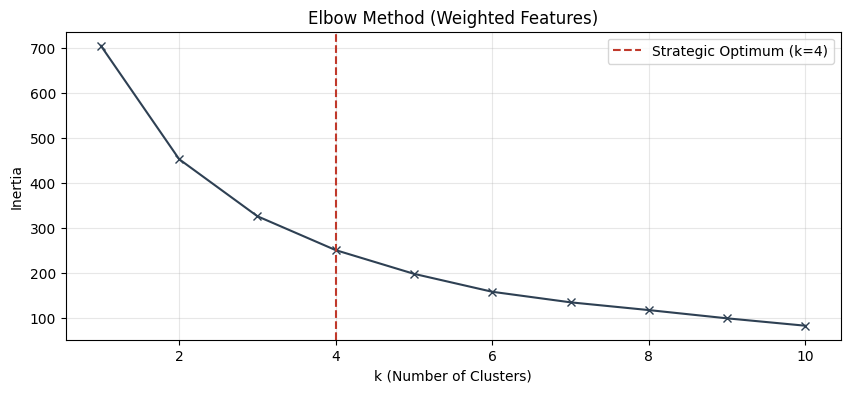

🎯 Clustering complete. Vendors assigned to Strategic Review tiers.


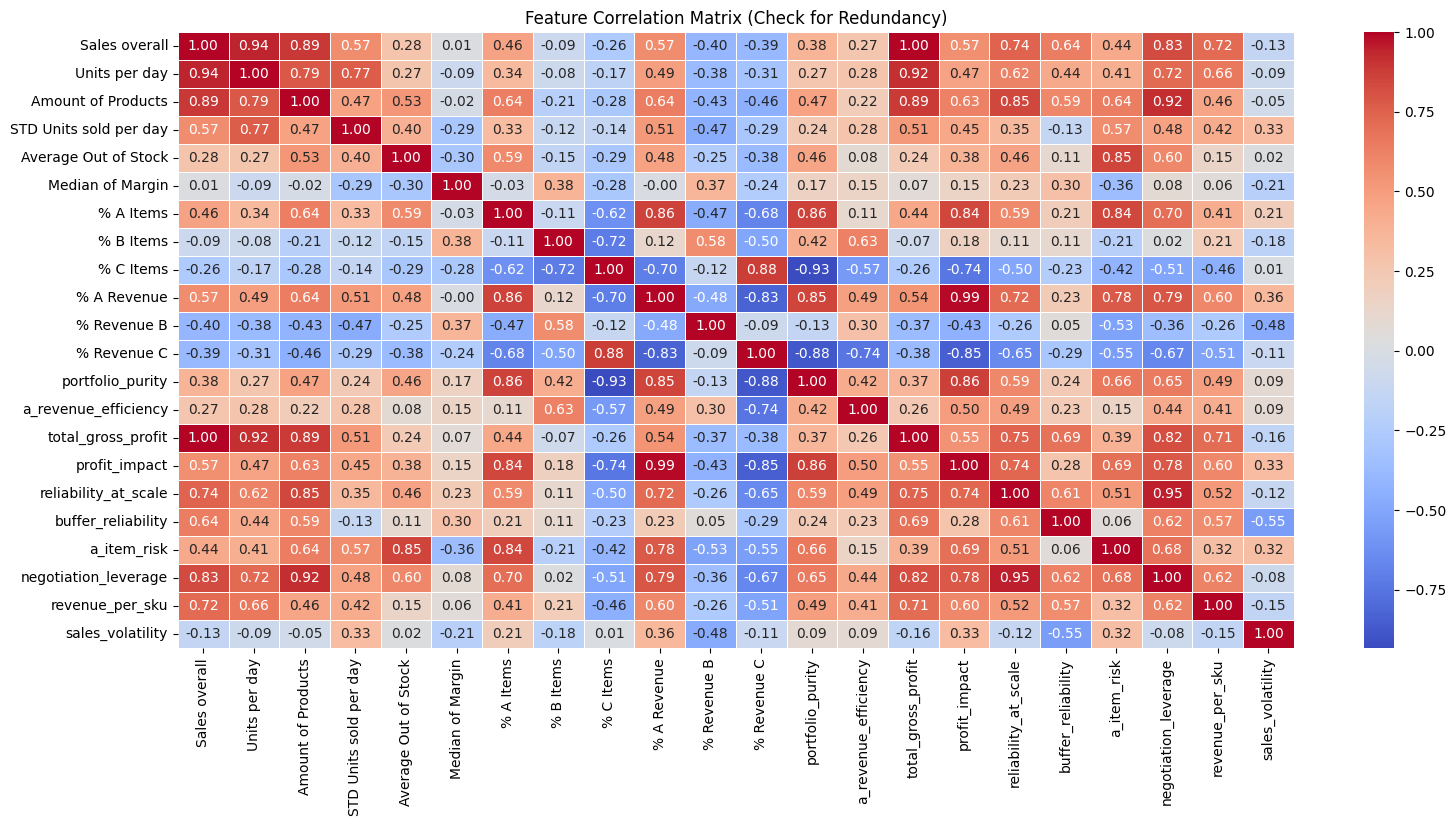

,count,mean,std,min,25%,50%,75%,max
portfolio_purity,22.0,-0.260909,0.316888,-1.000000,-0.427500,-0.210000,-0.035000,0.180000
a_revenue_efficiency,22.0,2.477503,0.995886,0.000000,2.188447,2.633333,3.158333,3.680000
total_gross_profit,22.0,7288.550314,8101.369693,76.720600,2381.158525,4640.772100,10958.778500,32695.941600
profit_impact,22.0,0.298536,0.150505,0.000000,0.182250,0.328850,0.418575,0.499800
reliability_at_scale,22.0,3.408794,0.720962,1.609438,3.278201,3.423981,3.802144,4.753711
buffer_reliability,22.0,569.170075,588.700667,15.140187,116.377192,367.957505,760.940083,1974.790997
a_item_risk,22.0,5.889218,5.188321,0.000000,1.888200,4.742400,8.827275,21.542400
negotiation_leverage,22.0,34.514778,12.065183,8.352547,27.339321,34.799744,42.050914,56.680137
revenue_per_sku,22.0,202.113927,132.634594,33.980000,139.203899,171.854024,274.013539,585.371538
sales_volatility,22.0,0.064793,0.065524,0.008646,0.018692,0.042755,0.089448,0.274426


In [2]:
# @title Feature Engineering & Weighted ML Model

# 1. FEATURE ENGINEERING
# A. Portfolio Quality & Density
df['portfolio_purity'] = df['% A Items'] - df['% C Items']
df['a_revenue_efficiency'] = df['% A Revenue'] / (df['% A Items'] + 0.01)

# B. Profitability & Cash Flow (Absolute values)
df['total_gross_profit'] = df['Sales overall'] * df['Median of Margin']
df['profit_impact'] = df['Median of Margin'] * df['% A Revenue']

# C. Reliability & Operational Risk
df['reliability_at_scale'] = (1 - (df['Average Out of Stock'] / 100)) * np.log1p(df['Amount of Products'])
# Safety stock coverage based on your 30-day threshold
df['buffer_reliability'] = (df['Units per day'] * 30) / (df['STD Units sold per day'] + 1)
# Risk of stockouts on high-revenue items
df['a_item_risk'] = df['Average Out of Stock'] * df['% A Revenue']

# D. Negotiation & Efficiency
df['negotiation_leverage'] = np.log1p(df['Sales overall']) * np.log1p(df['Amount of Products'])
df['revenue_per_sku'] = df['Sales overall'] / (df['Amount of Products'] + 1)
df['sales_volatility'] = df['STD Units sold per day'] / (df['Units per day'] + 0.1)

print("✅ All 10 engineered features calculated.")

# 2. FEATURE SELECTION
base_features = [
    'Sales overall', 'Units per day', 'Amount of Products',
    'STD Units sold per day', 'Average Out of Stock', 'Median of Margin',
    '% A Items', '% B Items', '% C Items',
    '% A Revenue', '% Revenue B', '% Revenue C'
]

engineered_features = [
    'portfolio_purity', 'a_revenue_efficiency', 'total_gross_profit',
    'profit_impact', 'reliability_at_scale', 'buffer_reliability',
    'a_item_risk', 'negotiation_leverage', 'revenue_per_sku', 'sales_volatility'
]

all_features_list = base_features + engineered_features
df_eda = df[all_features_list]

# 3. STANDARDIZATION & STRATEGIC WEIGHTING
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_eda.fillna(0))
X_weighted = pd.DataFrame(X_scaled, columns=all_features_list)

# --- APPLY STRATEGIC WEIGHTS ---
weights = {
    'Sales overall': 2.5,           # Primary anchor for "Strategic" status
    'Average Out of Stock': 1.5,    # Primary anchor for "Operational Risk"
    'total_gross_profit': 1.7,      # Financial importance
    'portfolio_purity': 1.5,        # Quality of the vendor's catalog
    'negotiation_leverage': 1.2     # Power in the market
}

for feature, weight in weights.items():
    if feature in X_weighted.columns:
        X_weighted[feature] *= weight

print(f"⚖️ Strategic weights applied to {len(weights)} key drivers.")

# 4. K-MEANS CLUSTERING (Using Weighted Data)
inertia = []
K = range(1, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_weighted)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 4))
plt.plot(K, inertia, 'bx-', color='#2E4053')
plt.xlabel('k (Number of Clusters)')
plt.ylabel('Inertia')
plt.title('Elbow Method (Weighted Features)')
plt.axvline(x=4, color='#C0392B', linestyle='--', label='Strategic Optimum (k=4)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Final Fit
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_weighted)

# 5. PCA FOR VISUALIZATION (Based on weighted features)
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_weighted)
df['PCA1'] = pca_results[:, 0]
df['PCA2'] = pca_results[:, 1]

# Calculate weighted centroids for the map
centroids_weighted = kmeans.cluster_centers_
centroids_2d_array = pca.transform(centroids_weighted)
centroids_2d = pd.DataFrame(centroids_2d_array, columns=['PCA1', 'PCA2'])
centroids_2d['Cluster'] = range(4)

print("🎯 Clustering complete. Vendors assigned to Strategic Review tiers.")

# 6. CORRELATION & SUMMARY
plt.figure(figsize=(18, 8))
sns.heatmap(df_eda.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix (Check for Redundancy)')
plt.show()

display(df[engineered_features].describe().T)

In [4]:
# @title ML: Weighted Clustering & Explainability Logic

# 1. K-MEANS & PCA
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_weighted)

pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_weighted)
df['PCA1'], df['PCA2'] = pca_results[:, 0], pca_results[:, 1]

# 2. IDENTIFY THE "STRATEGIC ANCHOR"
# We find which cluster is the 'Strategic' one (Top-Right)
c2d = df.groupby('Cluster')[['PCA1', 'PCA2']].mean()
strat_id = c2d[(c2d['PCA1'] > c2d['PCA1'].mean()) & (c2d['PCA2'] > c2d['PCA2'].mean())].index[0]

# 3. EXPLAINABILITY LOGIC (The "Why")
def explain_vendor(row):
    if row['Cluster'] == strat_id:
        return "High Revenue & High Purity"

    # Compare key metrics to find the biggest gap
    reasons = []
    if row['% C Items'] > 40: reasons.append(f"Catalog Bloat ({row['% C Items']:.0f}% C-Items)")
    if row['Average Out of Stock'] > 15: reasons.append(f"Supply Risk ({row['Average Out of Stock']:.0f}% OOS)")
    if row['portfolio_purity'] < 0: reasons.append("Low Portfolio Purity")
    if row['Sales overall'] < df['Sales overall'].median(): reasons.append("Low Strategic Scale")

    return reasons[0] if reasons else "Mixed Performance"

df['Primary Driver'] = df.apply(explain_vendor, axis=1)

# 4. RE-CALC CENTROIDS
weighted_centroids_high_dim = kmeans.cluster_centers_
centroids_2d_array = pca.transform(weighted_centroids_high_dim)
centroids_2d = pd.DataFrame(centroids_2d_array, columns=['PCA1', 'PCA2'])
centroids_2d['Cluster'] = range(4)

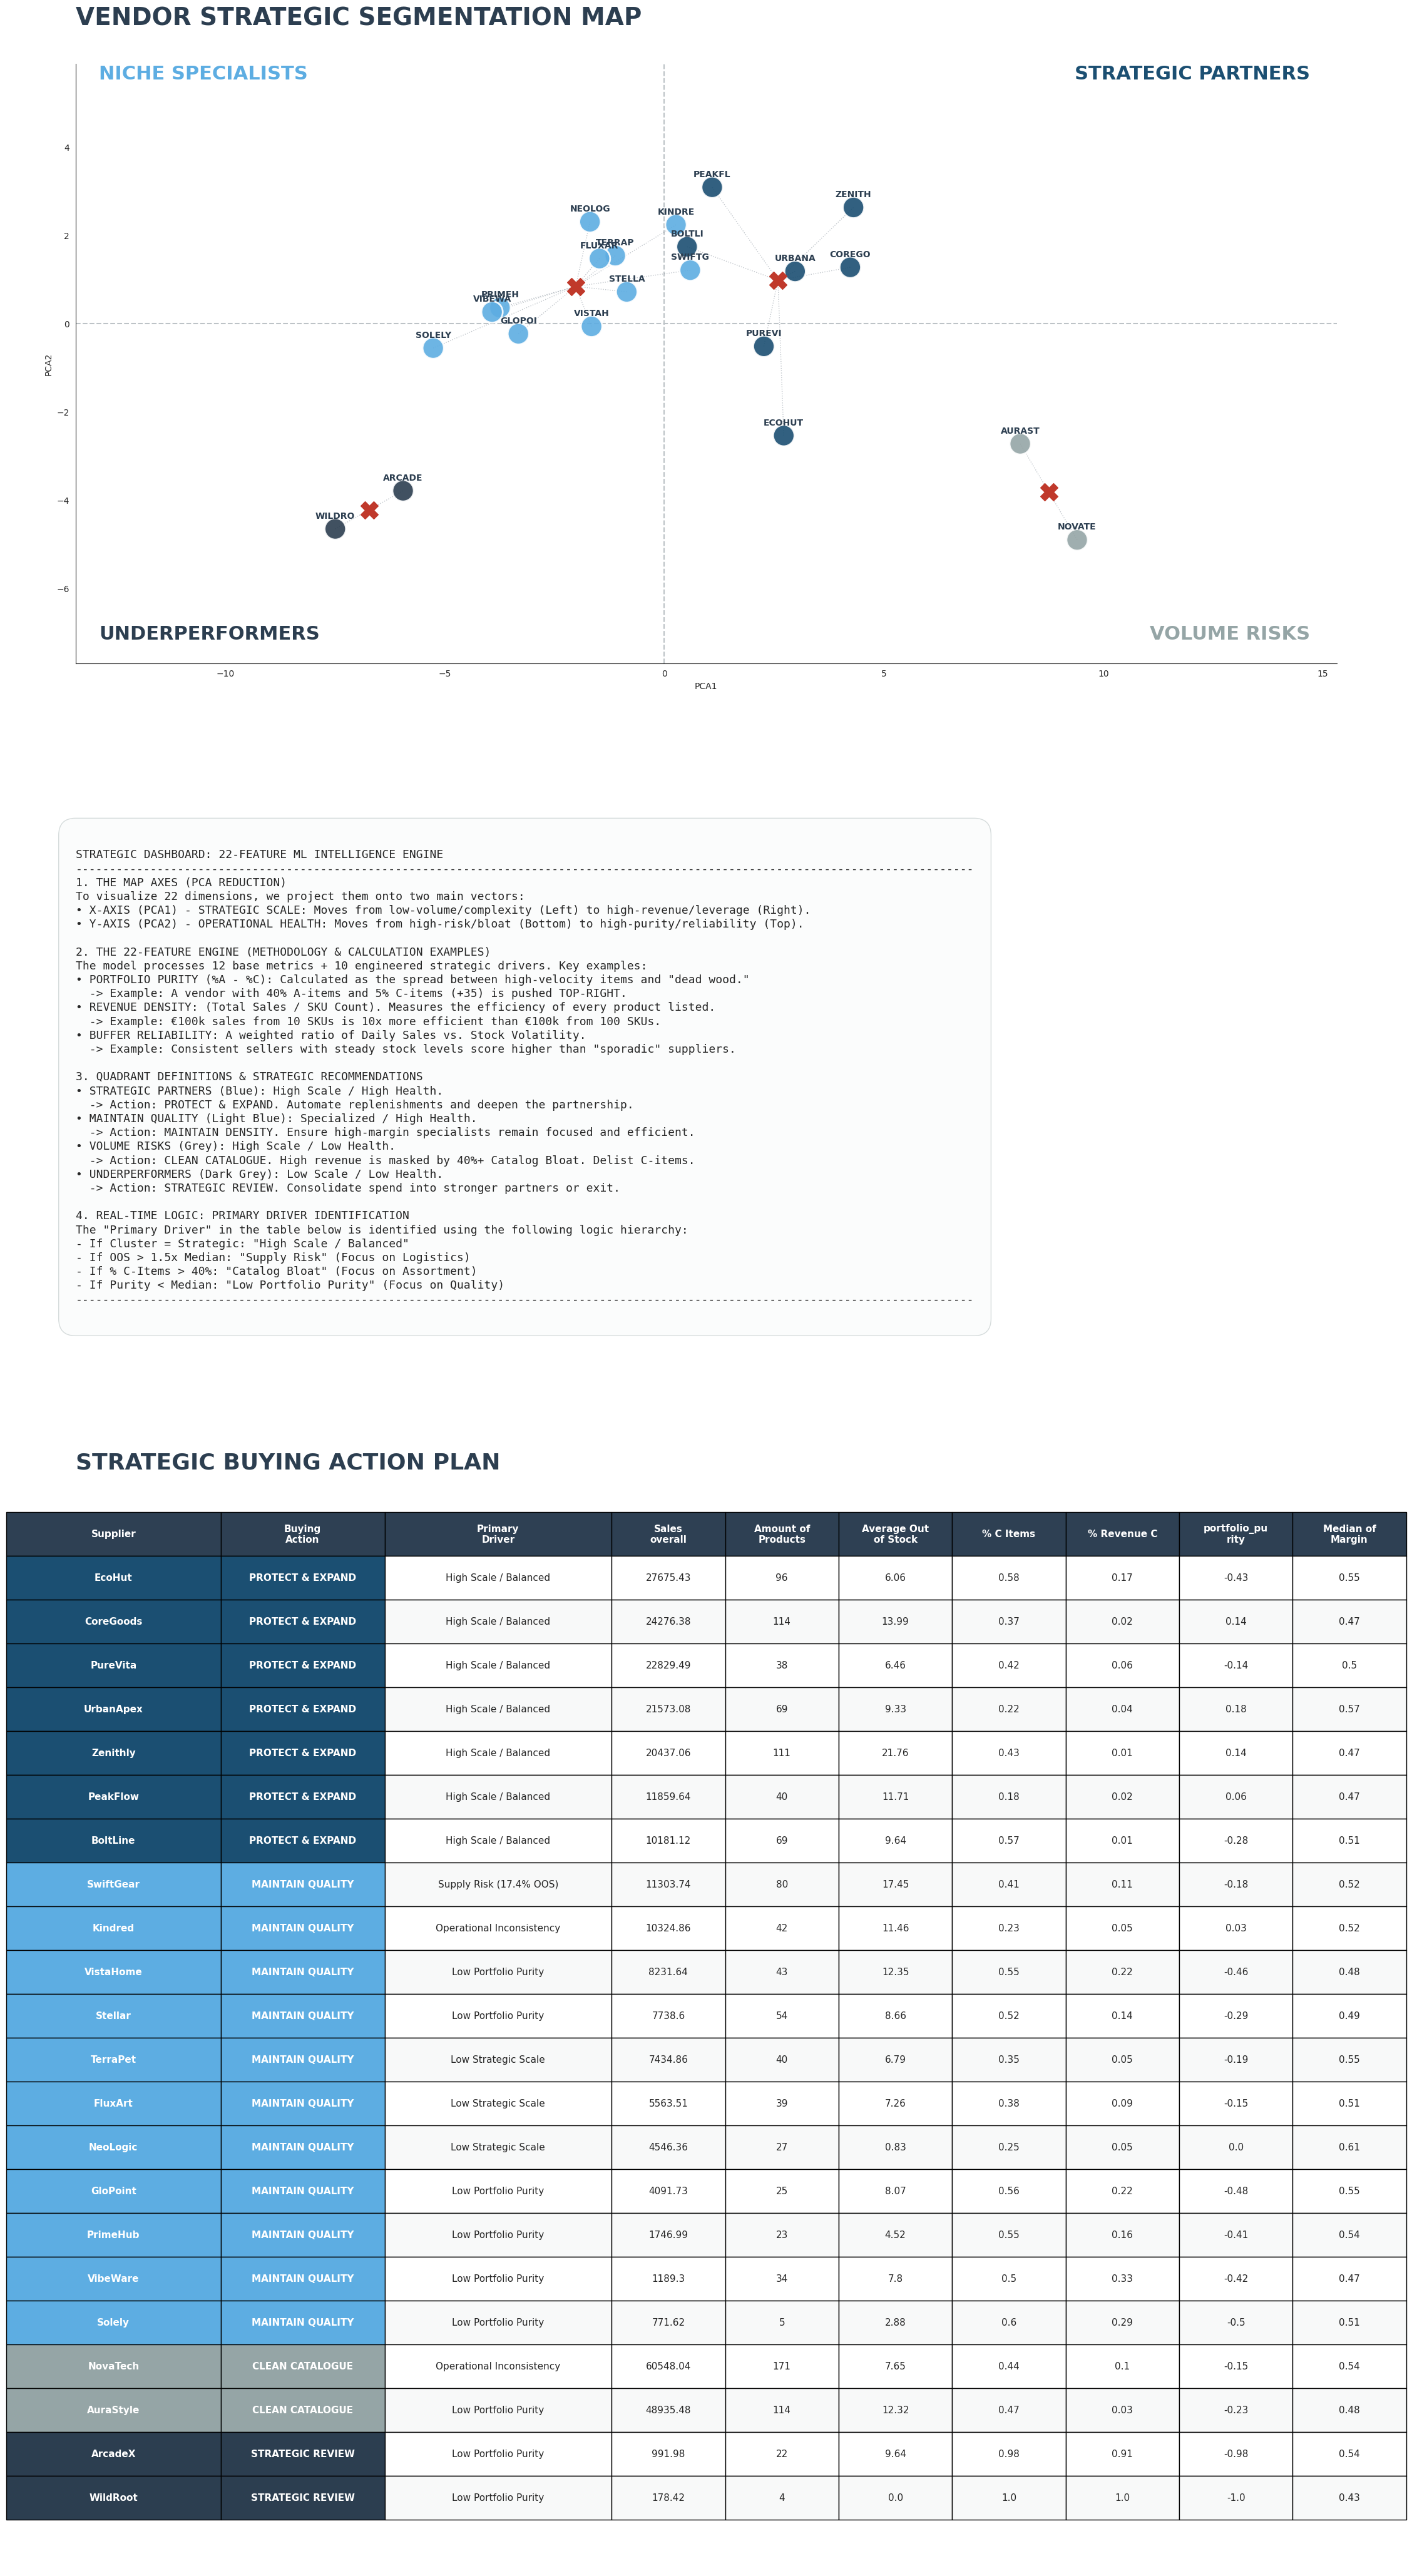

✅ Success! Dashboard rendered and outcome saved as: Strategic_Vendor_Analysis_2026.csv
📊 CSV contains 29 columns including Drivers, Clusters, and Recommendations.


In [6]:
# @title Final Strategic Vendor Dashboard

# 1. SETUP LAYOUT
fig = plt.figure(figsize=(26, 52))
gs = GridSpec(3, 1, height_ratios=[1.0, 1.0, 1.8], hspace=0.15)

ax_plot = fig.add_subplot(gs[0])
ax_text = fig.add_subplot(gs[1])
ax_table = fig.add_subplot(gs[2])
sns.set_style("white")

# 2. DYNAMIC LOGIC MAPPING
c2d = centroids_2d.set_index('Cluster')
strat_id = c2d[(c2d['PCA1'] > c2d['PCA1'].mean()) & (c2d['PCA2'] > c2d['PCA2'].mean())].index[0]
niche_id = c2d[(c2d['PCA1'] <= c2d['PCA1'].mean()) & (c2d['PCA2'] > c2d['PCA2'].mean())].index[0]
risk_id = c2d[(c2d['PCA1'] > c2d['PCA1'].mean()) & (c2d['PCA2'] <= c2d['PCA2'].mean())].index[0]
review_id = c2d[(c2d['PCA1'] <= c2d['PCA1'].mean()) & (c2d['PCA2'] <= c2d['PCA2'].mean())].index[0]

action_map = {strat_id: "PROTECT & EXPAND", niche_id: "MAINTAIN QUALITY",
              risk_id: "CLEAN CATALOGUE", review_id: "STRATEGIC REVIEW"}
priority_map = {strat_id: 0, niche_id: 1, risk_id: 2, review_id: 3}
cluster_colors = {strat_id: "#1B4F72", niche_id: "#5DADE2", risk_id: "#95A5A6", review_id: "#2C3E50"}

# 3. STRATEGIC MAP
ax_plot.set_title("VENDOR STRATEGIC SEGMENTATION MAP", fontsize=28, weight='bold', color='#2C3E50', loc='left', pad=45)
ax_plot.axhline(0, color='#BDC3C7', linewidth=1.5, linestyle='--')
ax_plot.axvline(0, color='#BDC3C7', linewidth=1.5, linestyle='--')

x_min, x_max = df['PCA1'].min(), df['PCA1'].max()
y_min, y_max = df['PCA2'].min(), df['PCA2'].max()
x_range, y_range = x_max - x_min, y_max - y_min
ax_plot.set_xlim(x_min - (x_range * 0.35), x_max + (x_range * 0.35))
ax_plot.set_ylim(y_min - (y_range * 0.35), y_max + (y_range * 0.35))

for i in range(len(df)):
    cluster_id = df.iloc[i]['Cluster']
    centroid = centroids_2d[centroids_2d['Cluster'] == cluster_id].iloc[0]
    ax_plot.plot([df.iloc[i]['PCA1'], centroid['PCA1']], [df.iloc[i]['PCA2'], centroid['PCA2']],
                 color='#2C3E50', linestyle=':', linewidth=1, alpha=0.3)

sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette=cluster_colors,
                s=600, alpha=0.9, edgecolor='white', zorder=2, legend=False, ax=ax_plot)
ax_plot.scatter(centroids_2d['PCA1'], centroids_2d['PCA2'], color='#C0392B', marker='X', s=400, zorder=3)

for i in range(len(df)):
    label = str(df.iloc[i]['Supplier'])[:6].upper()
    ax_plot.text(df.iloc[i]['PCA1'], df.iloc[i]['PCA2'] + (y_range * 0.03), label,
                 fontsize=10, weight='bold', ha='center', color='#2C3E50')

curr_xmin, curr_xmax = ax_plot.get_xlim()
curr_ymin, curr_ymax = ax_plot.get_ylim()
ax_plot.text(curr_xmax*0.96, curr_ymax*0.94, "STRATEGIC PARTNERS", color='#1B4F72', weight='bold', ha='right', size=22)
ax_plot.text(curr_xmin*0.96, curr_ymax*0.94, "NICHE SPECIALISTS", color='#5DADE2', weight='bold', ha='left', size=22)
ax_plot.text(curr_xmax*0.96, curr_ymin*0.94, "VOLUME RISKS", color='#95A5A6', weight='bold', ha='right', va='bottom', size=22)
ax_plot.text(curr_xmin*0.96, curr_ymin*0.94, "UNDERPERFORMERS", color='#2C3E50', weight='bold', ha='left', va='bottom', size=22)
sns.despine(ax=ax_plot)

# 4. GLOSSARY

glossary_text = f"""
STRATEGIC DASHBOARD: 22-FEATURE ML INTELLIGENCE ENGINE
------------------------------------------------------------------------------------------------------------------------------------
1. THE MAP AXES (PCA REDUCTION)
To visualize 22 dimensions, we project them onto two main vectors:
• X-AXIS (PCA1) - STRATEGIC SCALE: Moves from low-volume/complexity (Left) to high-revenue/leverage (Right).
• Y-AXIS (PCA2) - OPERATIONAL HEALTH: Moves from high-risk/bloat (Bottom) to high-purity/reliability (Top).

2. THE 22-FEATURE ENGINE (METHODOLOGY & CALCULATION EXAMPLES)
The model processes 12 base metrics + 10 engineered strategic drivers. Key examples:
• PORTFOLIO PURITY (%A - %C): Calculated as the spread between high-velocity items and "dead wood."
  -> Example: A vendor with 40% A-items and 5% C-items (+35) is pushed TOP-RIGHT.
• REVENUE DENSITY: (Total Sales / SKU Count). Measures the efficiency of every product listed.
  -> Example: €100k sales from 10 SKUs is 10x more efficient than €100k from 100 SKUs.
• BUFFER RELIABILITY: A weighted ratio of Daily Sales vs. Stock Volatility.
  -> Example: Consistent sellers with steady stock levels score higher than "sporadic" suppliers.

3. QUADRANT DEFINITIONS & STRATEGIC RECOMMENDATIONS
• STRATEGIC PARTNERS (Blue): High Scale / High Health.
  -> Action: PROTECT & EXPAND. Automate replenishments and deepen the partnership.
• MAINTAIN QUALITY (Light Blue): Specialized / High Health.
  -> Action: MAINTAIN DENSITY. Ensure high-margin specialists remain focused and efficient.
• VOLUME RISKS (Grey): High Scale / Low Health.
  -> Action: CLEAN CATALOGUE. High revenue is masked by 40%+ Catalog Bloat. Delist C-items.
• UNDERPERFORMERS (Dark Grey): Low Scale / Low Health.
  -> Action: STRATEGIC REVIEW. Consolidate spend into stronger partners or exit.

4. REAL-TIME LOGIC: PRIMARY DRIVER IDENTIFICATION
The "Primary Driver" in the table below is identified using the following logic hierarchy:
- If Cluster = Strategic: "High Scale / Balanced"
- If OOS > 1.5x Median: "Supply Risk" (Focus on Logistics)
- If % C-Items > 40%: "Catalog Bloat" (Focus on Assortment)
- If Purity < Median: "Low Portfolio Purity" (Focus on Quality)
------------------------------------------------------------------------------------------------------------------------------------
"""


ax_text.axis('off')
ax_text.text(0.0, 0.5, glossary_text, ha="left", va="center", fontsize=13, family='monospace', linespacing=1.3,
             bbox={"facecolor":"#FBFCFC", "edgecolor":"#D5DBDB", "boxstyle":"round,pad=1.5"})

# 5. DATA TABLE
ax_table.axis('off')
ax_table.text(0, 1.02, "STRATEGIC BUYING ACTION PLAN",
              transform=ax_table.transAxes, fontsize=26, weight='bold', color='#2C3E50', ha='left')

df_sorted = df.copy()
def get_primary_driver(row):
    if row['Cluster'] == strat_id: return "High Scale / Balanced"
    if row['Average Out of Stock'] > df['Average Out of Stock'].median() * 1.5: return f"Supply Risk ({row['Average Out of Stock']:.1f}% OOS)"
    if row['% C Items'] > 40: return f"Catalog Bloat ({row['% C Items']:.1f}% C-Items)"
    if row['portfolio_purity'] < df['portfolio_purity'].median(): return "Low Portfolio Purity"
    if row['Sales overall'] < df['Sales overall'].median(): return "Low Strategic Scale"
    return "Operational Inconsistency"

df_sorted['Primary Driver'] = df_sorted.apply(get_primary_driver, axis=1)
df_sorted['Sort_Priority'] = df_sorted['Cluster'].map(priority_map)
df_sorted['Buying Action'] = df_sorted['Cluster'].map(action_map)
df_sorted = df_sorted.sort_values(by=['Sort_Priority', 'Sales overall'], ascending=[True, False])

ceo_cols = [
    'Supplier', 'Buying Action', 'Primary Driver', 'Sales overall',
    'Amount of Products', 'Average Out of Stock', '% C Items',
    '% Revenue C', 'portfolio_purity', 'Median of Margin'
]
table_df = df_sorted[ceo_cols].round(2)
wrapped_labels = ["\n".join(textwrap.wrap(col, 12)) for col in table_df.columns]

the_table = ax_table.table(cellText=table_df.values, colLabels=wrapped_labels, loc='upper center', cellLoc='center')
the_table.auto_set_font_size(False)
the_table.set_fontsize(11)
the_table.scale(1.1, 4.2)

for j, col_name in enumerate(table_df.columns):
    header_cell = the_table.get_celld()[(0, j)]
    header_cell.set_facecolor('#2E4053'); header_cell.get_text().set_color('white'); header_cell.get_text().set_weight('bold')


    if j == 0: width = 0.17
    elif j == 1: width = 0.13
    elif j == 2: width = 0.18
    else: width = 0.09

    for i in range(len(table_df) + 1):
        the_table.get_celld()[(i, j)].set_width(width)
        if i > 0:
            cell = the_table.get_celld()[(i, j)]
            c_val = int(df_sorted.iloc[i-1]['Cluster'])
            if j in [0, 1]:
                cell.set_facecolor(cluster_colors[c_val]); cell.get_text().set_color('white'); cell.get_text().set_weight('bold')
            elif i % 2 == 0: cell.set_facecolor('#F8F9F9')

plt.show()

# 6. DATA EXPORT
export_df = df_sorted.copy()
export_df = export_df.sort_values(by=['Sort_Priority', 'Sales overall'], ascending=[True, False])
filename = "Strategic_Vendor_Analysis_2026.csv"
export_df.to_csv(filename, index=False)

print(f"✅ Success! Dashboard rendered and outcome saved as: {filename}")
print(f"📊 CSV contains {len(export_df.columns)} columns including Drivers, Clusters, and Recommendations.")